<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/17_regression_crossval/17_2_MLR/17_2_4_4_notes_on_curves.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a># Notes on Alpha Tuning Curves and Learning Curves

This notebook reviews and clarifies two important diagnostic visualizations: **Alpha Tuning Curves** and **Learning Curves**. These tools help you understand and debug your models.

**What this is:** A review notebook that clarifies concepts from Part 4. It does not introduce new information.

**What we assume:** You already know what regularization is (Ridge, Lasso) and why we tune hyperparameters. This notebook focuses on how to visualize that tuning process.

## Setup: A Small Training Subset

We use a subset of the California housing dataset (500 training samples) to make the curves more interesting. With fewer samples, overfitting becomes more visible.

In [1]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the California housing dataset
cal_housing = fetch_california_housing(as_frame=True)
X = cal_housing.data
y = cal_housing.target

# Use ALL 8 features
X_full = X

# Split into full train/test first
X_train_full, X_test, y_train_full, y_test = train_test_split(X_full, y, test_size=0.2, random_state=42)

# Then take a SUBSET for training to make curves more interesting
np.random.seed(42)
subset_idx = np.random.choice(len(X_train_full), size=500, replace=False)
X_train = X_train_full.iloc[subset_idx]
y_train = y_train_full.iloc[subset_idx]

print(f"Using all {X_full.shape[1]} features")
print(f"Training subset: {len(X_train)} samples (for visible curves)")
print(f"Full training set available: {len(X_train_full)} samples")

Using all 8 features
Training subset: 500 samples (for visible curves)
Full training set available: 16512 samples


---

## Part 1: Alpha Tuning Curves

### What it shows

An alpha tuning curve plots both the **training score** and the **cross-validation score** against different values of alpha (the regularization strength).

**Why we use it:** It visualizes the bias-variance tradeoff directly. Instead of just hearing "there's a tradeoff," you can *see* it.

### How to read it

- **Left side (low alpha):** The model is unconstrained, behaving like ordinary least squares. The training score is high, but the gap between training and validation scores indicates overfitting.
- **Right side (high alpha):** The penalty is so strong that coefficients get crushed toward zero. Both scores drop because the model is too simple to capture patterns — underfitting.
- **Middle (optimal alpha):** The validation score peaks. This is your sweet spot.

### Key insight

The distance between the training and validation curves is your visual indicator of overfitting. When the gap is large, your model is memorizing training data rather than learning generalizable patterns.

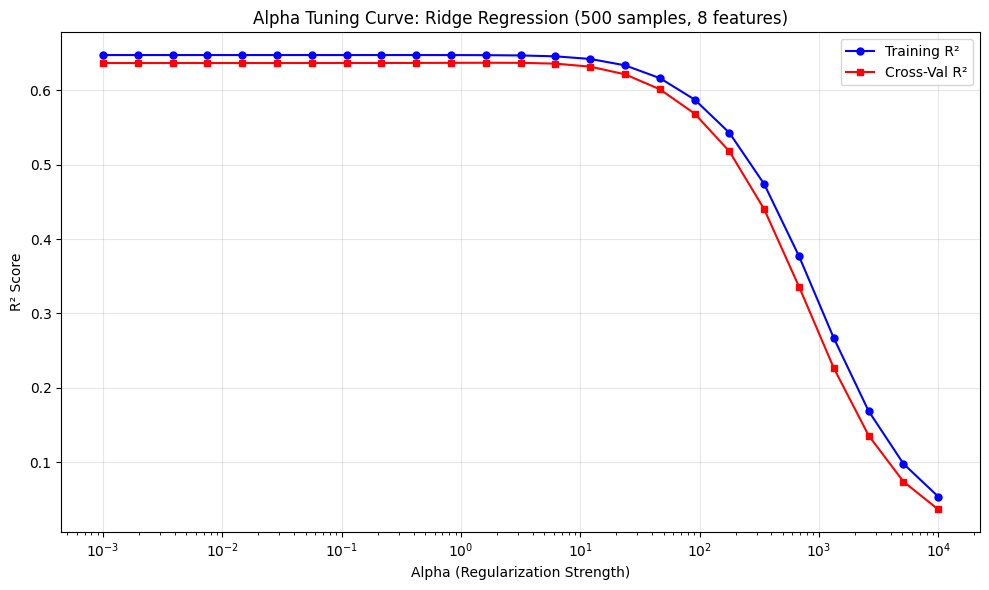

In [2]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Test a range of alpha values
alphas = np.logspace(-3, 4, 25)  # 25 values from 0.001 to 10000

train_scores = []
cv_scores = []

for alpha in alphas:
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=alpha))
    ])
    
    # Cross-validation score
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2')
    cv_scores.append(scores.mean())
    
    # Training score
    pipeline.fit(X_train, y_train)
    train_scores.append(pipeline.score(X_train, y_train))

# Plot
plt.figure(figsize=(10, 6))
plt.semilogx(alphas, train_scores, 'b-o', label='Training R²', markersize=5)
plt.semilogx(alphas, cv_scores, 'r-s', label='Cross-Val R²', markersize=5)
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('R² Score')
plt.title('Alpha Tuning Curve: Ridge Regression (500 samples, 8 features)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### What to notice in this curve

1. **The training curve (blue)** starts high (~0.65). With 500 samples and 8 features, the unconstrained model can fit the training data very well.

2. **There IS a visible gap** between training and validation at low alpha. This gap represents overfitting — the model is memorizing training data.

3. **As alpha increases**, the gap changes. At very high alpha (right side), both curves drop dramatically — the model is now underfitting.

4. **The peak** of the validation curve is your optimal alpha — the sweet spot between underfitting and overfitting.

5. **The dramatic drop at high alpha** shows severe underfitting — the regularization is so strong the model can't capture any pattern.

---

## Part 2: Learning Curves

### What it shows

A learning curve plots both the training score and validation score against the **number of training samples**.

**Why we use it:** It answers the question: "Would more data help my model?"

### How to read it

- **Large gap between curves:** The model is overfitting (high variance). Adding more data might help because the model isn't seeing enough examples to learn the pattern.
- **Both curves converge at a low value:** The model is underfitting (high bias). The bottleneck is model complexity, not data quantity. More data won't help.
- **Validation curve still rising:** The model hasn't plateaued. More data would likely improve performance.

### Key insight

Learning curves separate the problem into three buckets: (1) need more data, (2) need simpler model, (3) need more complex model.

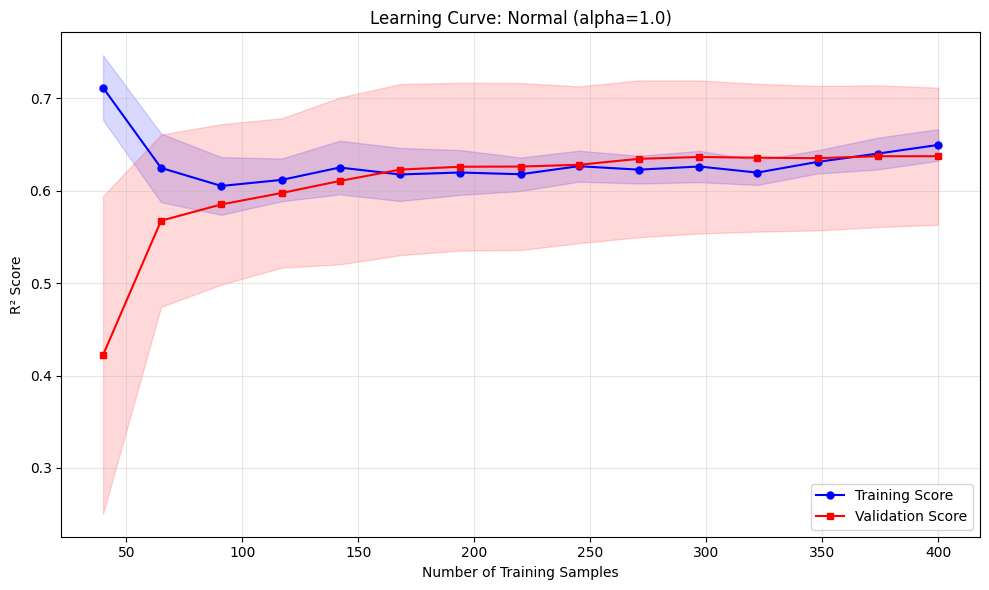

In [3]:
from sklearn.model_selection import learning_curve

# Use Ridge with a moderate alpha (roughly optimal from alpha curve)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])

# Generate learning curve with more granular sampling
train_sizes, train_lc_scores, test_lc_scores = learning_curve(
    pipeline, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 15),
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

train_mean = train_lc_scores.mean(axis=1)
train_std = train_lc_scores.std(axis=1)
test_mean = test_lc_scores.mean(axis=1)
test_std = test_lc_scores.std(axis=1)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'b-o', label='Training Score', markersize=5)
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')
plt.plot(train_sizes, test_mean, 'r-s', label='Validation Score', markersize=5)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='red')
plt.xlabel('Number of Training Samples')
plt.ylabel('R² Score')
plt.title('Learning Curve: Normal (alpha=1.0)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### What to notice in this curve

1. **There IS a visible gap** between training and validation scores at smaller sample sizes.

2. **The curves are still rising** as we add more data. The validation score hasn't plateaued — more data would help.

3. **The shaded bands** show variability across cross-validation folds.

4. **This is the "need more data" scenario** — if you see this pattern in production, gathering more data is likely to improve your model.

---

## Part 3: Underfitting Example

Let's also show what underfitting looks like. We'll use a very high alpha on the same data.

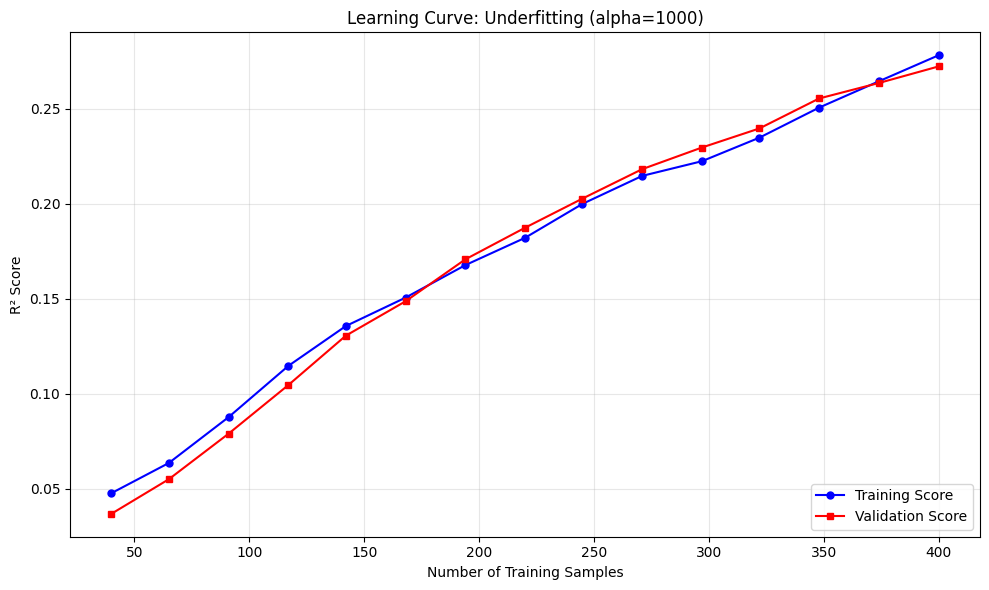

In [4]:
# Generate learning curve with very high alpha (underfitting)
pipeline_underfit = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1000))  # Very high alpha = severe underfitting
])

train_sizes, train_lc_scores, test_lc_scores = learning_curve(
    pipeline_underfit, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 15),
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

train_mean = train_lc_scores.mean(axis=1)
test_mean = test_lc_scores.mean(axis=1)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'b-o', label='Training Score', markersize=5)
plt.plot(train_sizes, test_mean, 'r-s', label='Validation Score', markersize=5)
plt.xlabel('Number of Training Samples')
plt.ylabel('R² Score')
plt.title('Learning Curve: Underfitting (alpha=1000)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### What to notice in this curve

1. **Both curves are very close together** — there's almost no gap.

2. **Both curves converge at a LOW value** — around R² = 0.2-0.3. The model is too simple to capture the patterns in the data.

3. **This is the underfitting pattern** — adding more data won't help. You need a more complex model (lower alpha, or more features).

4. **Contrast with the previous learning curve** — there, the curves converge at ~0.6 and are still rising. Here, they plateau at ~0.25.

---

## Summary: When to Use Which

### Alpha Tuning Curve
- **Question:** What is the best regularization strength?
- **X-axis:** Alpha (penalty strength)
- **Use when:** You want to find the optimal hyperparameter and understand the bias-variance tradeoff

### Learning Curve
- **Question:** Would more data help?
- **X-axis:** Number of training samples
- **Use when:** You want to diagnose whether you need more data, a simpler model, or a more complex model

### Three Learning Curve Patterns

| Pattern | What you see | What it means | What to do |
|---------|-------------|---------------|------------|
| Gap between curves | Training high, validation low | Overfitting | More data, more regularization, or fewer features |
| Both curves rising | Both scores increasing with data | Need more data | Gather more training examples |
| Both converge low | Both plateau at low value | Underfitting | More complex model or more features |

### How they work together

In practice, you often use both:
1. First, tune your alpha (or other hyperparameters) to find the best model architecture
2. Then, check the learning curve to see if gathering more data would be worthwhile

Both are essential tools in your model debugging toolkit.

---

## Quick Reference

| Curve | X-axis | Shows | Problem if gap is large | Problem if gap is small |
|-------|--------|-------|------------------------|------------------------|
| Alpha Tuning | Alpha value | Best regularization strength | Overfitting | N/A (look for peak instead) |
| Learning Curve | Training set size | Need for more data | Overfitting (high variance) | Underfitting (high bias) |